In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,regularizers,callbacks,optimizers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import plot_model
from PIL import Image

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

c:\Users\HP\Desktop\Brain Tumor\brain_tumor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


In [3]:
print(os.listdir(path))

['Testing', 'Training']


In [4]:
train_path = path+'/Training'
test_path = path+'/Testing'

In [5]:
classes = ["Glioma", "Meningioma", "Pituitary tumor", "No tumor"]

In [6]:
num_classes = len(classes)

In [7]:
train_dataset,val_dataset = image_dataset_from_directory(train_path,image_size=(224,224),subset='both',validation_split=0.2,seed=42)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Using 1120 files for validation.


In [8]:
class_name = os.listdir(train_path)[0]

# first image path
img_name = os.listdir(train_path + '/' + class_name)[0]

img_path = train_path + '/' + class_name + '/' + img_name

# open image
img = Image.open(img_path)

print(img.mode)

print("Image Size:", img.size)

L
Image Size: (512, 512)


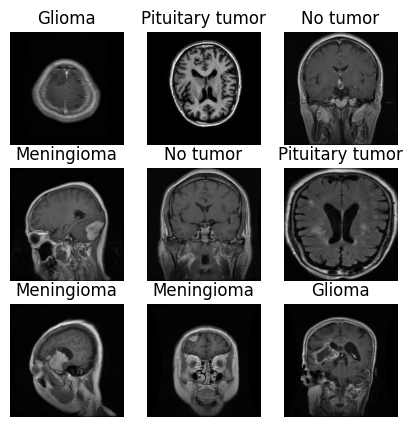

In [9]:
plt.figure(figsize=(5,5))
for images,labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(classes[int(labels[i])])
        plt.axis("off")

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),

])

def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x


def build_improved_cnn():
    inputs = keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = conv_block(x, filters=64, dropout_rate=0.15)
    x = conv_block(x, filters=128, dropout_rate=0.25)
    x = conv_block(x, filters=256, dropout_rate=0.35)
    x = conv_block(x, filters=512, dropout_rate=0.45)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model_exp3 = keras.Model(inputs, outputs, name="model_exp3")
    return model_exp3


model_exp3 = build_improved_cnn()

keras.utils.plot_model(model_exp3, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [11]:
epochs = 1

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]


model_exp3.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-4,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), # if output activition is softmax then it's false.
    metrics=[keras.metrics.SparseCategoricalAccuracy(
    name="sparse_categorical_accuracy")],
)
history_exp3 = model_exp3.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=callbacks_list
)

 16/140 ━━━━━━━━━━━━━━━━━━━━ 1:56:59 57s/step - loss: 1.2074 - sparse_categorical_accuracy: 0.5115


KeyboardInterrupt



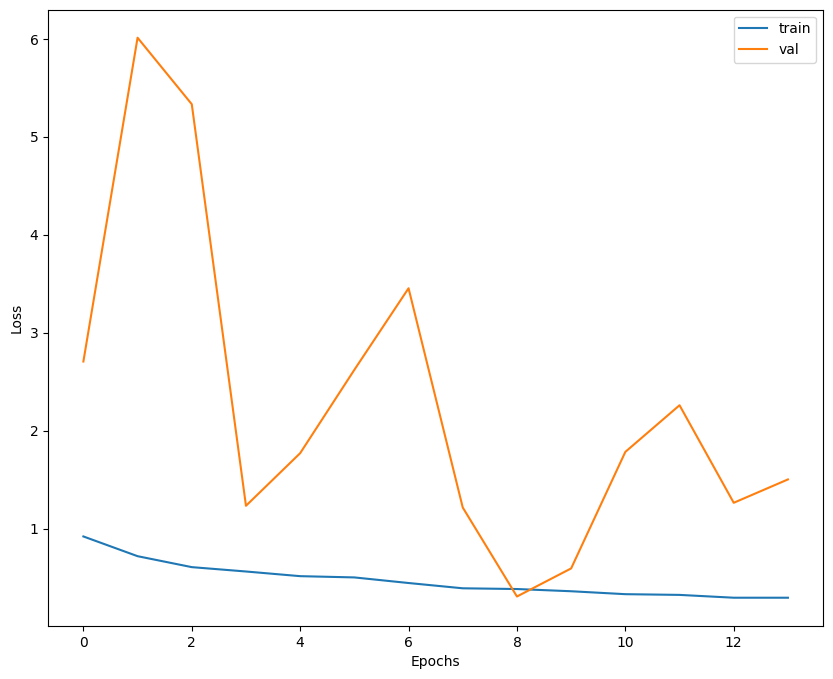

In [13]:
plt.figure(figsize=(10,8))
plt.plot(history_exp3.history['loss'],label='train')
plt.plot(history_exp3.history['val_loss'],label='val')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

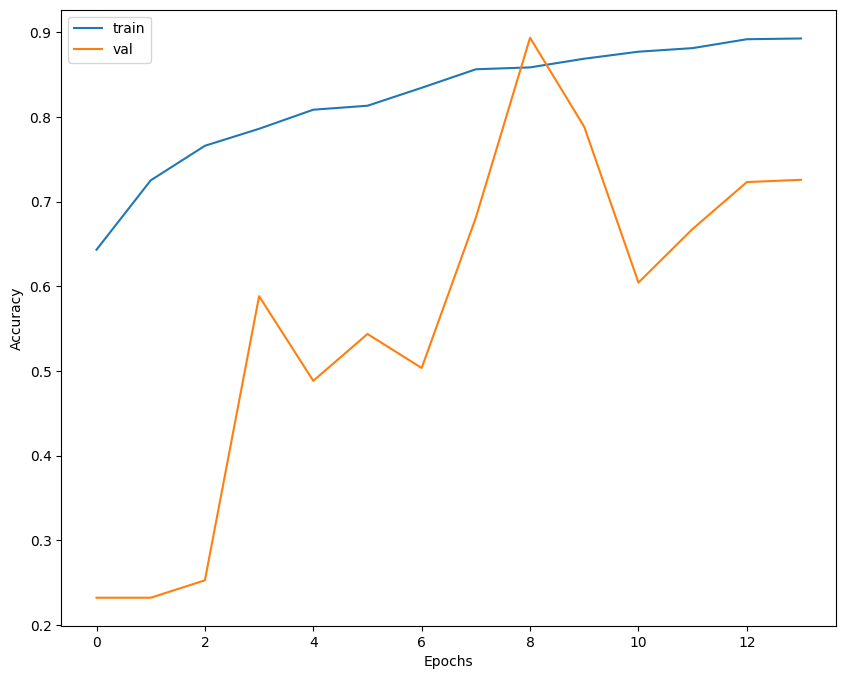

In [14]:
plt.figure(figsize=(10,8))
plt.plot(history_exp3.history['sparse_categorical_accuracy'],label='train')
plt.plot(history_exp3.history['val_sparse_categorical_accuracy'],label='val')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
test_dataset = image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    shuffle=False
)

test_loss, test_acc = model_exp3.evaluate(test_dataset)

print("Test Accuracy:", test_acc)
print("Test_loss", test_loss)

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - loss: 0.7151 - sparse_categorical_accuracy: 0.7906
Test Accuracy: 0.7906249761581421
Test_loss 0.7151140570640564


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
# true labels
y_true = np.concatenate(
    [y for x, y in test_dataset],
    axis=0
)

In [18]:
# predictions
y_pred_probs = model_exp3.predict(test_dataset)

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step


In [19]:
# convert probabilities to class index
y_pred = np.argmax(y_pred_probs, axis=1)

In [20]:
# classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

                 precision    recall  f1-score   support

         Glioma       0.91      0.62      0.74       400
     Meningioma       0.66      0.74      0.70       400
Pituitary tumor       0.74      0.98      0.85       400
       No tumor       0.94      0.82      0.87       400

       accuracy                           0.79      1600
      macro avg       0.81      0.79      0.79      1600
   weighted avg       0.81      0.79      0.79      1600



In [21]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)

In [22]:
cm

array([[249,  89,  55,   7],
       [  9, 296,  81,  14],
       [  7,   0, 393,   0],
       [ 10,  63,   0, 327]])

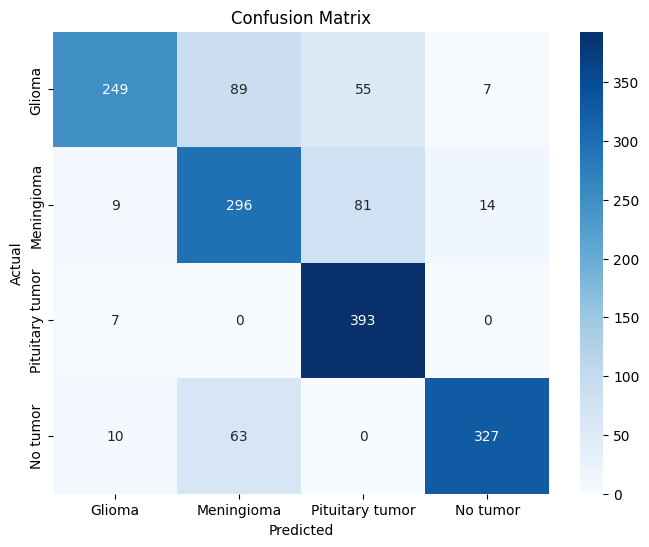

In [23]:
# plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
MODEL_PATH = "Brain_tumer_cnn.keras"

model_exp3.save(MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: Brain_tumer_cnn.keras
